# Bulk Topological Invariants — Winding Number and Phase Diagram

Computes the winding number of $q(k) = t_1 + t_2 e^{-ik}$, maps the topological
phase diagram, and visualises the $q(k)$ trajectory for three representative
parameter choices.


In [1]:
import sys
sys.path.insert(0, "..")   # find src/nh_topo from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo.config import load_all, get_physics_params, get_figure_dir
from pathlib import Path

cfg = load_all(config_dir="../config")
p   = get_physics_params(cfg)

# Quick confirmation
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}")
print(f"Topological: t2/t1 = {p['t2']/p['t1']:.2f} > 1 → |nu|={nt.topological_invariant(p['t1'], p['t2'])}")


t1=0.8, t2=1.2, gamma=0.3, N=20
Topological: t2/t1 = 1.50 > 1 → |nu|=1


In [2]:
nu = nt.topological_invariant(p['t1'], p['t2'])
xi = nt.localization_length(p['t1'], p['t2'])
print(f"|nu| = {nu}  ({'topological' if nu == 1 else 'trivial'})")
print(f"Localization length xi = {xi:.3f} unit cells")
print(f"PT-breaking threshold: gamma_c = |t2-t1| = {abs(p['t2']-p['t1']):.3f}")
print(f"Current gamma = {p['gamma']:.3f}  ({'< gamma_c: unbroken' if p['gamma'] < abs(p['t2']-p['t1']) else '>= gamma_c: broken'})")

# Phase diagram data
t2_scan = np.linspace(0.05, 2.5 * p['t1'], 500)
nu_scan = np.array([nt.topological_invariant(p['t1'], t2v) for t2v in t2_scan])

# q(k) trajectories for three cases
cases = [
    ("trivial ($t_2/t_1=0.75$)",  "#ff7f0e", nt.qk_trajectory(p['t1'], 0.6)),
    (f"operating ($t_2/t_1={p['t2']/p['t1']:.1f}$)", "#1f77b4", nt.qk_trajectory(p['t1'], p['t2'])),
    ("deep topo ($t_2/t_1=2.0$)", "#2ca02c", nt.qk_trajectory(p['t1'], 2.0 * p['t1'])),
]


|nu| = 1  (topological)
Localization length xi = 2.466 unit cells
PT-breaking threshold: gamma_c = |t2-t1| = 0.400
Current gamma = 0.300  (< gamma_c: unbroken)


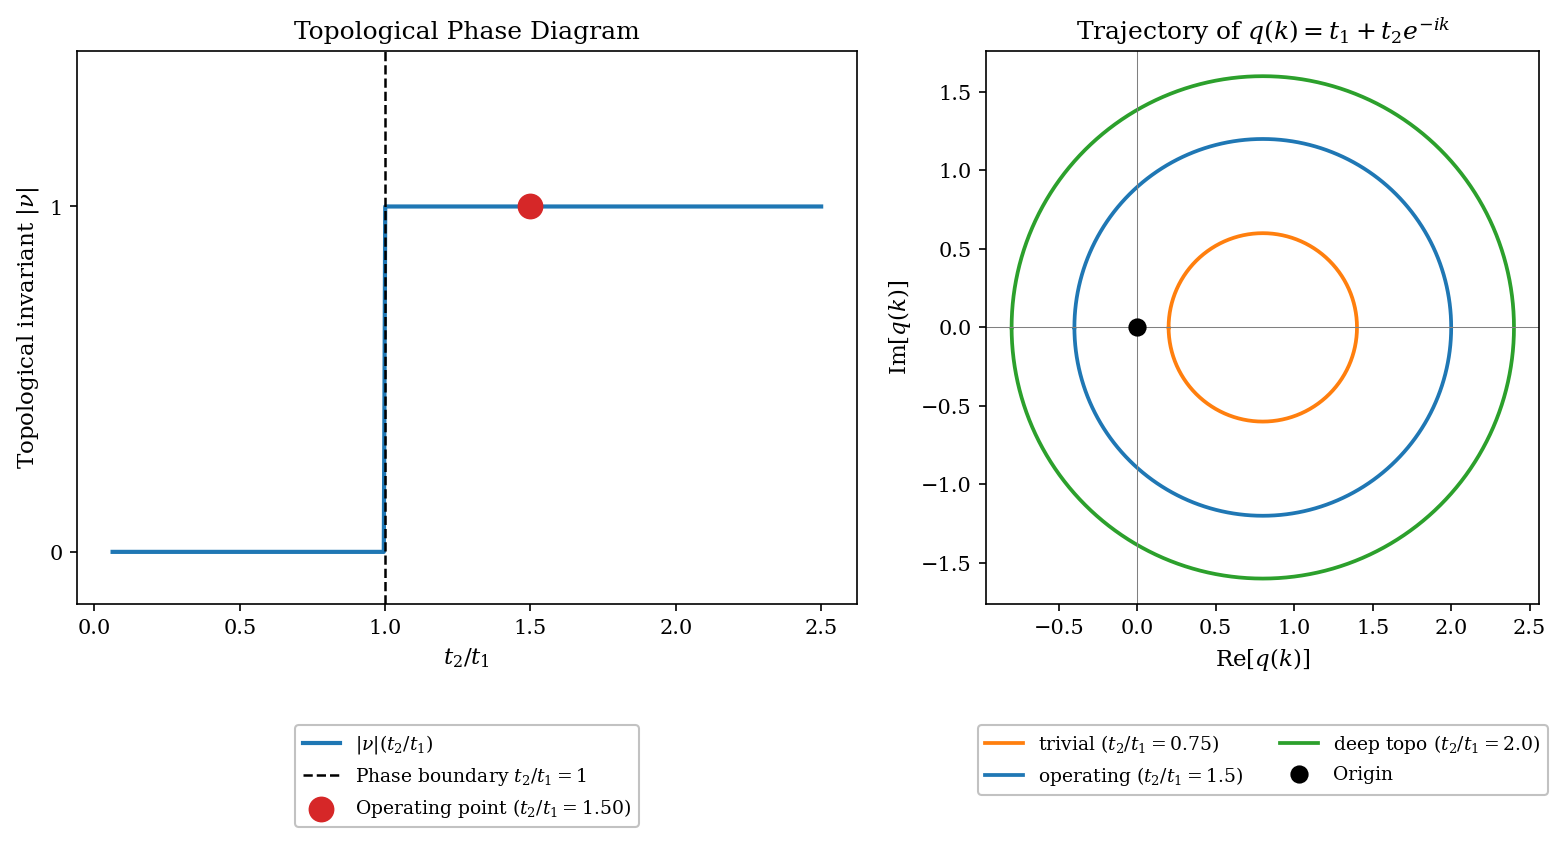

In [3]:
fig, axes = nt.plotting.plot_phase_diagram(
    p['t1'], p['t2'], nu, t2_scan, nu_scan, cases)
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '02_topological_invariants'), "01_phase_diagram")
plt.show()


**Bulk–edge correspondence** holds here because hopping is reciprocal
($H_{{ij}} = H_{{ji}}$), which ensures the GBZ equals the standard BZ.
The loss $\gamma$ enters only the diagonal of $H(k)$ and does not affect $q(k)$,
so the winding number is independent of $\gamma$.
